In [21]:
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score

In [13]:
class SkinLesionDataset(Dataset):
    def __init__(self, master_csv, img_dir, split_name='train', transform=None):
        self.df = pd.read_csv(master_csv)
        
        # filter only for train data
        self.df = self.df[self.df['split'] == split_name].reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        
        # strict 5 class
        self.label_map = {'MEL': 0, 'NV': 1, 'BCC': 2, 'BKL': 3, 'AKIEC': 4}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Get filename and label
        img_filename = self.df.loc[idx, 'image_id']
        string_label = str(self.df.loc[idx, 'label']).upper()
        dataset_domain = self.df.loc[idx, 'domain']
        
        # so images can be kept in seperate folders
        img_path = os.path.join(self.img_dir, dataset_domain, img_filename)
        
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        # Convert to tensor
        label_tensor = torch.tensor(self.label_map[string_label], dtype=torch.long)
        
        return image, label_tensor

In [14]:
baseline_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Initialize the Dataset
train_dataset = SkinLesionDataset(
    master_csv="../data/raw/master_metadata_split.csv",
    img_dir="../data/raw/", 
    split_name='train',
    transform=baseline_transforms
)

val_dataset = SkinLesionDataset(
    master_csv="../data/raw/master_metadata_split.csv",
    img_dir="../data/raw/", 
    split_name='val',
    transform=baseline_transforms
)

# Load Data
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

print(f"Training Images Loaded: {len(train_dataset)}")
print(f"Validation Images Loaded: {len(val_dataset)}")

Training Images Loaded: 19742
Validation Images Loaded: 2194


# Load Image to Check

/home/timothytoonen/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Batch Image Tensor Shape: torch.Size([32, 3, 224, 224])
Batch Label Tensor Shape: torch.Size([32])


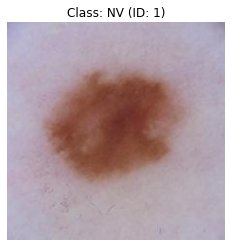

In [10]:
images, labels = next(iter(train_loader))

print(f"Batch Image Tensor Shape: {images.shape}")
print(f"Batch Label Tensor Shape: {labels.shape}")

single_image = images[0]
single_label = labels[0].item()

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

denorm_image = single_image * std + mean
denorm_image = torch.clamp(denorm_image, 0, 1)

plt.figure(figsize=(4, 4))
plt.imshow(denorm_image.permute(1, 2, 0).numpy())

reverse_label_map = {0: 'MEL', 1: 'NV', 2: 'BCC', 3: 'BKL', 4: 'AKIEC'}
plt.title(f"Class: {reverse_label_map[single_label]} (ID: {single_label})")
plt.axis('off')
plt.show()

In [15]:
# labels_map = {'MEL': 0, 'NV': 1, 'BCC': 2, 'BKL': 3, 'AKIEC': 4}

# figure = plt.figure(figsize=(8, 8))
# cols, rows = 3, 3
# for i in range(1, cols * rows + 1):
#     sample_idx = torch.randint(len(train_dataset), size=(1,)).item()
#     images, labels = train_dataset[sample_idx]
#     figure.add_subplot(rows, cols, i)
#     plt.title(labels_map[labels])
#     plt.axis("off")
#     plt.imshow(img.squeeze(), cmap="gray")
# plt.show()

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Call ConvNeXt

In [17]:
weights = ConvNeXt_Tiny_Weights.DEFAULT
model = convnext_tiny(weights=weights)
model

ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

In [18]:
in_features = model.classifier[2].in_features
model.classifier[2] = nn.Linear(in_features, 5)

model = model.to(device)

y_train = train_dataset.df['label'].map({'MEL': 0, 'NV': 1, 'BCC': 2, 'BKL': 3, 'AKIEC': 4}).values
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)

# move to GPU
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

# Loss and Optimizer

In [19]:
criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)


# Model Training

In [ ]:

############################################
# Training loop
############################################
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Handles exactly one pass through the training data."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad(set_to_none=True) # Supercomputer memory optimization
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    return total_loss / total, 100. * correct / total

############################################
# validation loop
############################################

@torch.no_grad()
def validate_epoch(model, dataloader, criterion, device):
    """Handles exactly one pass through the validation data without gradients."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        # Collect for Scikit-Learn F1 calculation
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
    val_acc = 100. * correct / total
    val_f1 = f1_score(all_labels, all_preds, average='macro')
    
    return total_loss / total, val_acc, val_f1



############################################
# Main PipelineExecution
############################################
def training_pipeline(model, train_loader, val_loader, criterion, optimizer, device, epochs=10, save_path='best_convnext_baseline.pth'):
    """Orchestrates the phase functions and tracks the best model weights."""
    print(f"\n--- Starting Functional ConvNeXt Baseline Training on {device} ---")
    best_val_f1 = 0.0
    
    for epoch in range(epochs):
        start_time = time.time()
        
        # Execute Phases
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, val_f1 = validate_epoch(model, val_loader, criterion, device)
        
        epoch_time = time.time() - start_time
        
        # Console Logging
        print(f"Epoch {epoch+1}/{epochs} | Time: {epoch_time:.0f}s")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}% | Val Macro F1: {val_f1:.4f}")
        
        # Checkpointing against Macro F1 (Critical for imbalanced medical data)
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), save_path)
            print(f"  --> Weights saved! (New Best Val F1: {best_val_f1:.4f})")

In [ ]:
training_pipeline(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=10
)